# Basic Setups

In [73]:
import os
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings("ignore")

In [74]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from utils.data_generator import check_missing_value
DATA_DIR="../data"

# Load and clean data

## Load data from csv files with headers

In [75]:
df_bitcoin=pd.read_csv(os.path.join(DATA_DIR, "BTC-Daily.csv"))
df_bitcoin.head()

,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD
0,1646092800,2022-03-01 00:00:00,BTC/USD,43221.71,43626.49,43185.48,43185.48,49.006289,2.116360e+06
1,1646006400,2022-02-28 00:00:00,BTC/USD,37717.10,44256.08,37468.99,43178.98,3160.618070,1.364723e+08
2,1645920000,2022-02-27 00:00:00,BTC/USD,39146.66,39886.92,37015.74,37712.68,1701.817043,6.418008e+07
3,1645833600,2022-02-26 00:00:00,BTC/USD,39242.64,40330.99,38600.00,39146.66,912.724087,3.573010e+07
4,1645747200,2022-02-25 00:00:00,BTC/USD,38360.93,39727.97,38027.61,39231.64,2202.851827,8.642149e+07


## Preprocessing

In [76]:
# Check missing values
print("Missing check: " + str(check_missing_value(df_bitcoin)))

# Check duplicate
print("------------- Duplicate check -------------")
print(f"Number of duplicate rows: {df_bitcoin.duplicated().sum()}")

# date_time conversion to datetime
print("------------- Date time conversion -------------")
df_bitcoin['date']=pd.to_datetime(df_bitcoin['date'])
print(df_bitcoin["date"].head(5))
# Date range
print("------------- Date range -------------")
date_range = str(df_bitcoin["date"].dt.date.min()) + " to " +str(df_bitcoin["date"].dt.date.max())
print(date_range)

Missing check:             count  percentage
unix            0         0.0
date            0         0.0
symbol          0         0.0
open            0         0.0
high            0         0.0
low             0         0.0
close           0         0.0
Volume BTC      0         0.0
Volume USD      0         0.0
------------- Duplicate check -------------
Number of duplicate rows: 0
------------- Date time conversion -------------
0   2022-03-01
1   2022-02-28
2   2022-02-27
3   2022-02-26
4   2022-02-25
Name: date, dtype: datetime64[ns]
------------- Date range -------------
2014-11-28 to 2022-03-01


# Visualization

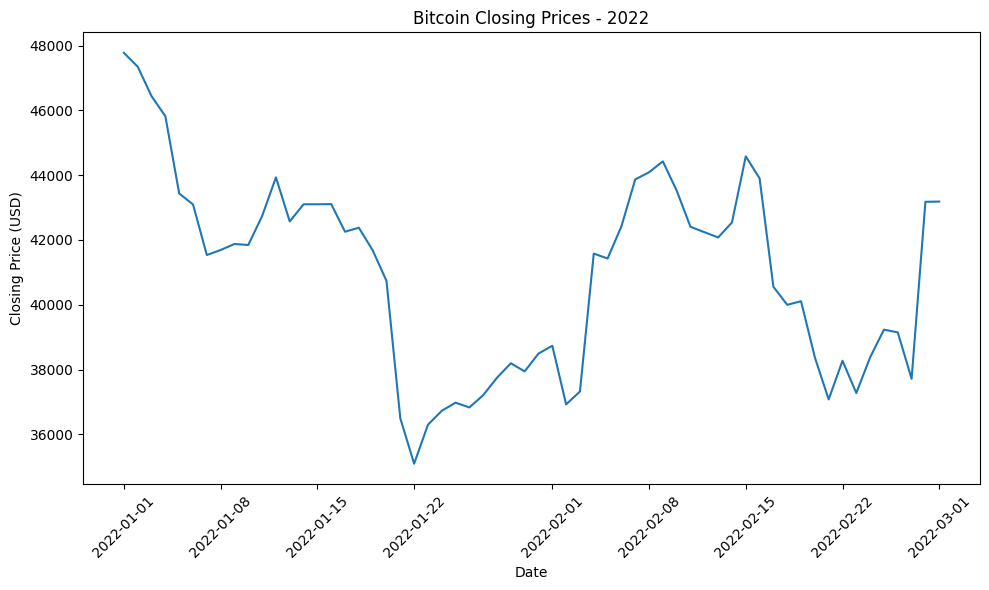

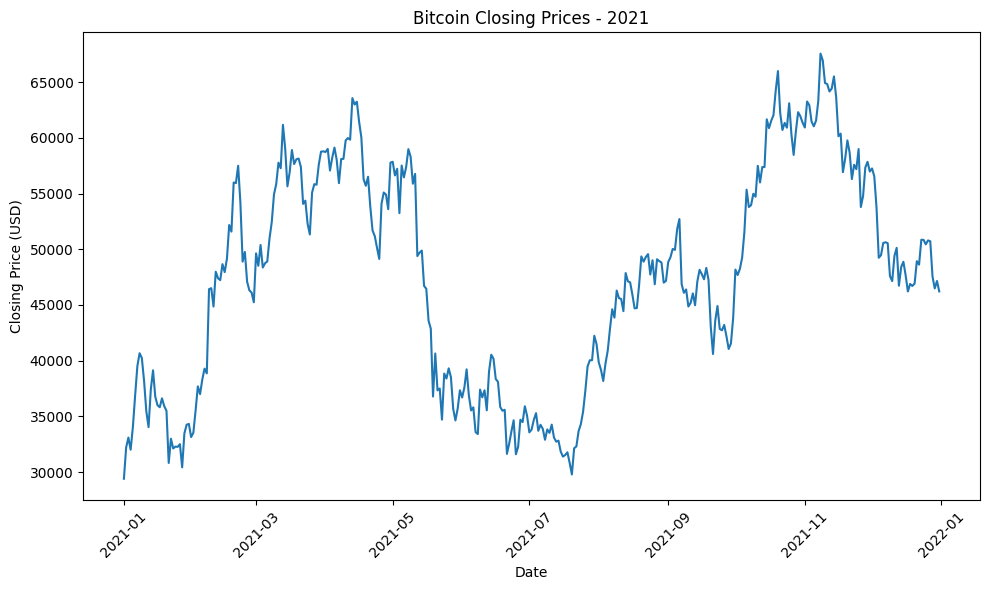

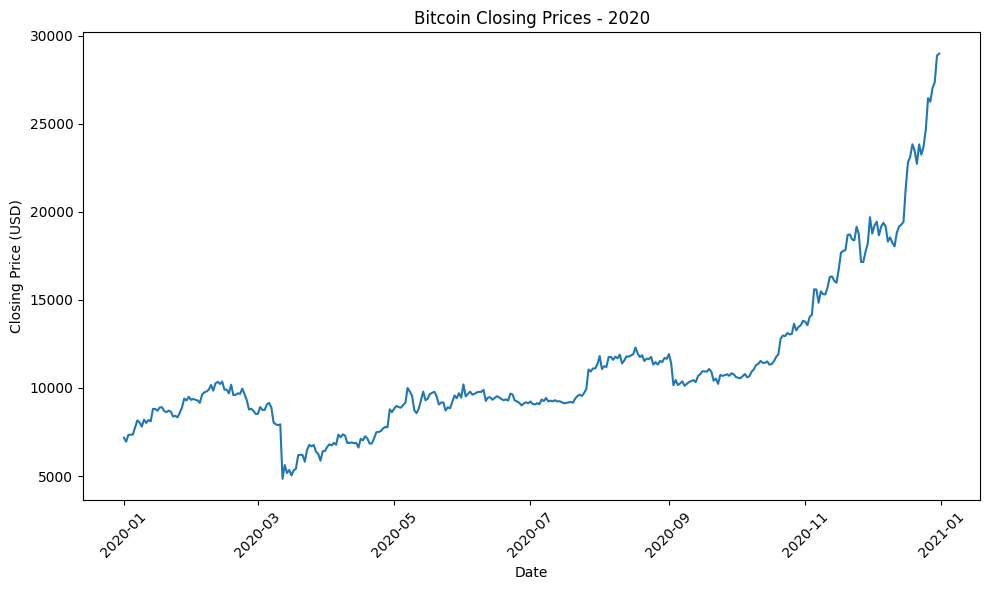

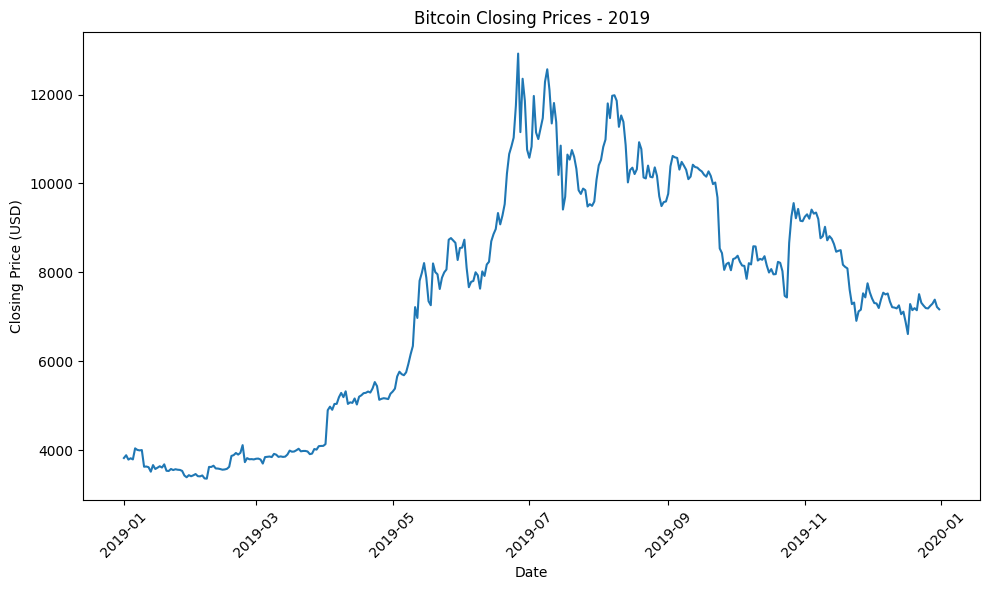

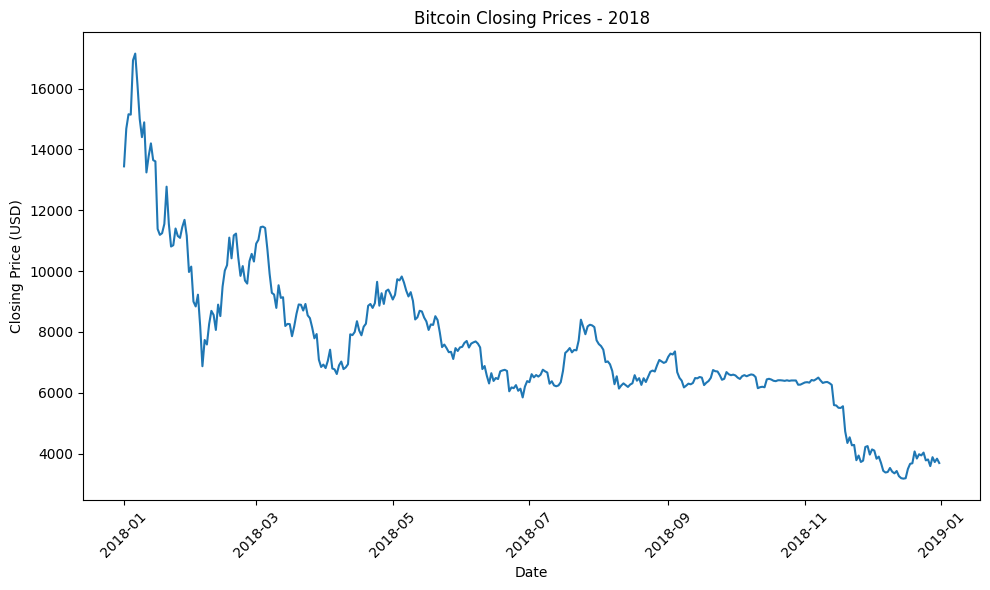

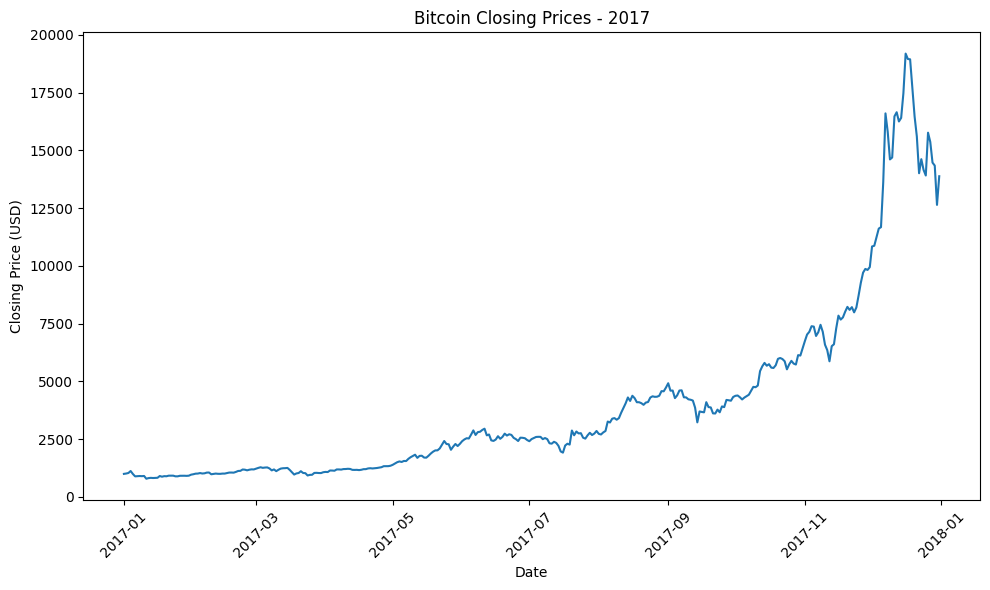

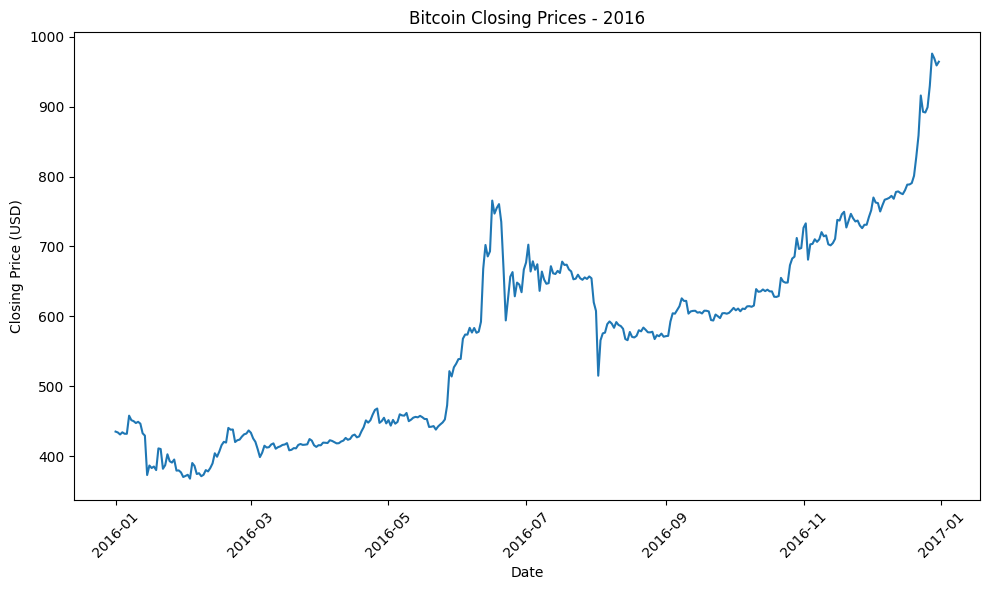

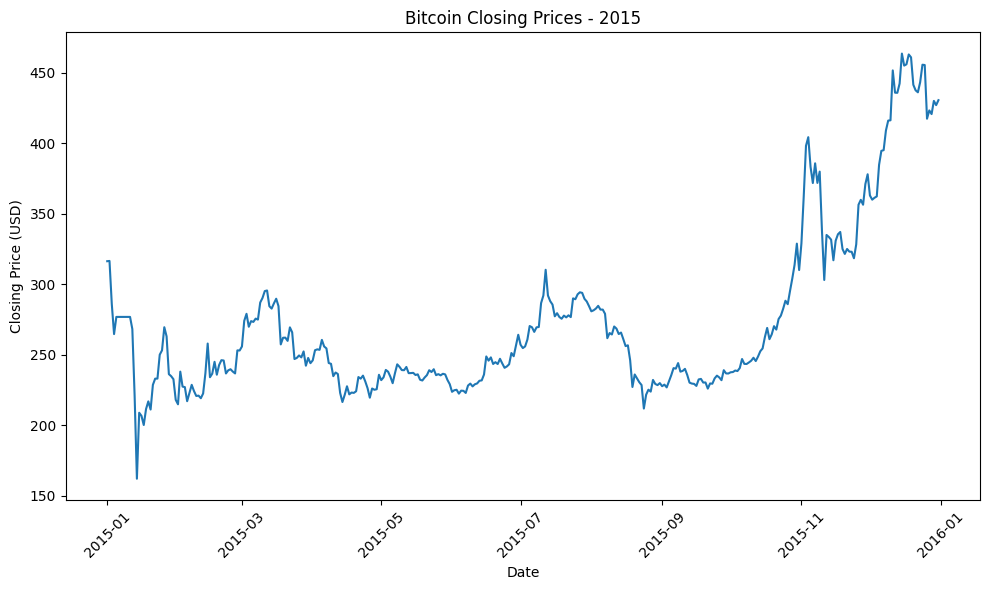

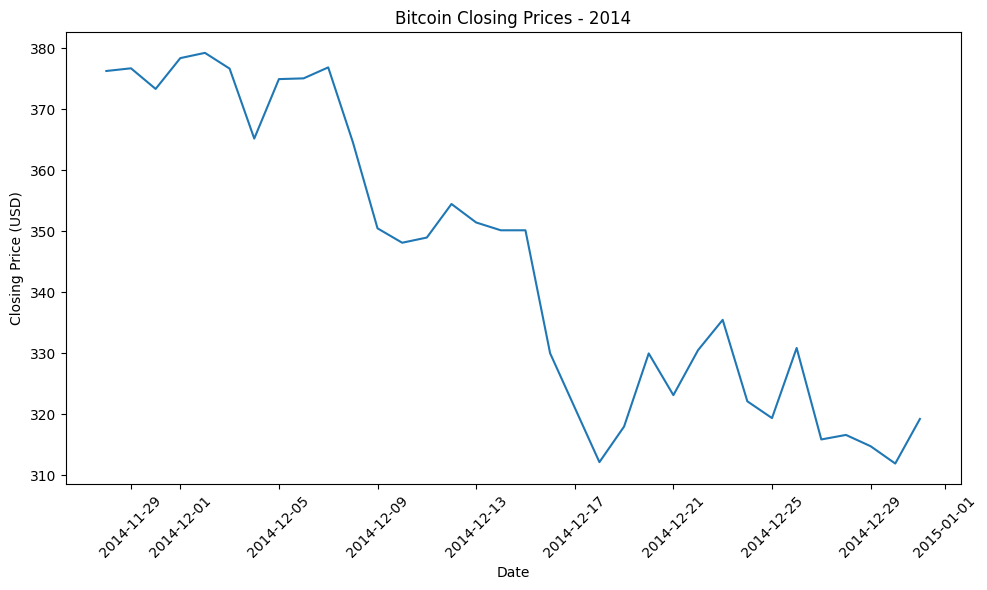

In [77]:
df_bitcoin["year"] = df_bitcoin["date"].dt.year
df_bitcoin["month"] = df_bitcoin["date"].dt.month
df_bitcoin["day"] = df_bitcoin["date"].dt.day


unique_years = df_bitcoin["year"].unique()
for year in unique_years:

    dates = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31", freq="D")
    year_month_day = pd.DataFrame({"date": dates})
    year_month_day["year"] = year_month_day["date"].dt.year
    year_month_day["month"] = year_month_day["date"].dt.month
    year_month_day["day"] = year_month_day["date"].dt.day


    merged_data = pd.merge(year_month_day, df_bitcoin, on=["year", "month", "day"], how="left")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(merged_data["date_x"], merged_data["close"])
    plt.title(f"Bitcoin Closing Prices - {year}")
    plt.xlabel("Date")
    plt.ylabel("Closing Price (USD)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Build Functions for Training

## Extract features and target

## Standard scaler

In [78]:
X=df_bitcoin[["open", "low", "high"]].to_numpy()
y=df_bitcoin[["close"]].to_numpy().reshape(-1,1)

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

In [80]:
scalar = StandardScaler()

X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

## Build Functions for training

In [81]:
def predict(x, theta):
    return x.dot(theta)   

def compute_loss(y_hat, y, m):
    return 1/m * (y_hat-y).T.dot(y_hat-y)

def gradient_compute(x, y_hat, y):
    k=2*(y_hat-y)
    return k.T.dot(x)

def update_theta(theta, gradient, lr):
    return theta - lr*gradient.T

In [82]:
def m_sample_gradient_descent(X_b, y, m=20, n_epochs=100, lr=0.01, n_features=3):
    N=X_b.shape[0]
    thetas = np.random.randn(n_features + 1, 1)
    losses=[]
    X_b=np.hstack((np.ones((N,1)), X_b))
    for _ in range(n_epochs):
        shuffled_indices = np.array(range(N)) if m in [1, N] else np.random.permutation(N)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(0, N, m):
            x=X_b_shuffled[i:i+m]
            y_i=y_shuffled[i:i+m]
            y_hat=predict(x, thetas)
            losses.append(compute_loss(y_hat, y_i, m)[0][0])
            gradient=gradient_compute(x, y_hat, y_i)/m
            thetas=update_theta(thetas, gradient, lr)
    
    plt.plot(losses)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Loss over Iterations')
    plt.show()
    return thetas

## Training and Evaluation

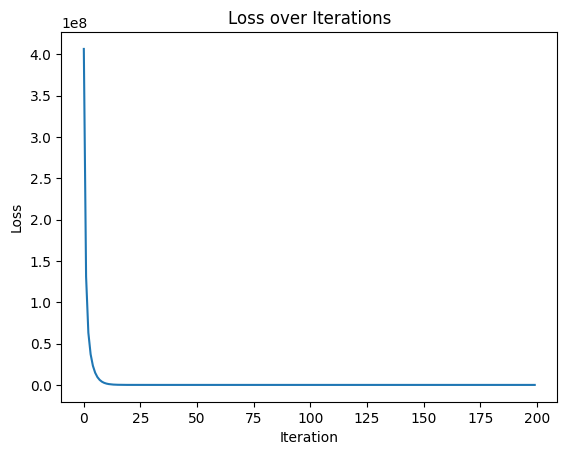

In [83]:
thetas=m_sample_gradient_descent(X_train_scaled, y_train, m=X_train_scaled.shape[0], n_epochs=200, lr=0.1)

In [84]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Make predictions on the test set
X_test_scaled_copy=np.hstack((np.ones((X_test_scaled.shape[0],1)), X_test_scaled))
y_pred = predict(X_test_scaled_copy, thetas)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Square Error (MSE):", round(mse, 4))
print("Mean Absolute Error (MAE):", round(mae, 4))
print("R-squared:", round(r2, 4))

Mean Square Error (MSE): 217331.0728
Mean Absolute Error (MAE): 212.9798
R-squared: 0.9991


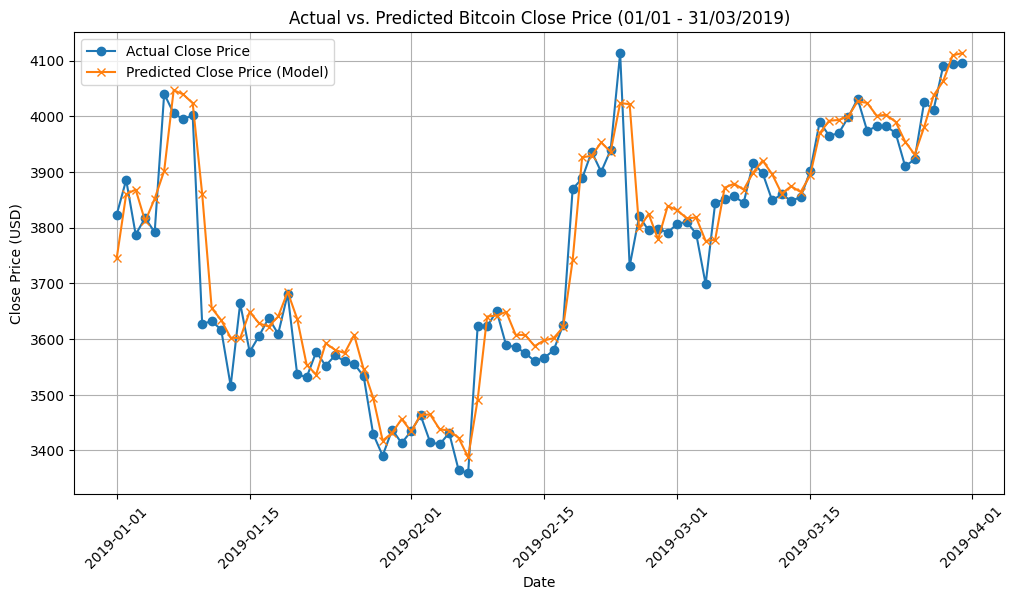

In [85]:
df=df_bitcoin.copy()
# Lọc dữ liệu 2019 Q1
df_2019_Q1 = df[(df["date"] >= "2019-01-01") & (df["date"] <= "2019-03-31")].copy()

# Chọn đúng các cột feature đã train
X_2019 = df_2019_Q1[["open", "low", "high"]].values
X_2019_scaled = scalar.transform(X_2019)   # dùng scalar đã fit trước đó
y_2019 = df_2019_Q1["close"].values
X_2019_scaled=np.hstack((np.ones((X_2019_scaled.shape[0],1)), X_2019_scaled))
# Dự đoán bằng mô hình
y_pred_2019 = predict(X_2019_scaled, thetas)

# Gắn vào dataframe để dễ vẽ
df_2019_Q1["predicted_close"] = y_pred_2019

# Vẽ biểu đồ
plt.figure(figsize=(12,6))
plt.plot(df_2019_Q1["date"], df_2019_Q1["close"], label="Actual Close Price", marker="o")
plt.plot(df_2019_Q1["date"], df_2019_Q1["predicted_close"], label="Predicted Close Price (Model)", marker="x")
plt.title("Actual vs. Predicted Bitcoin Close Price (01/01 - 31/03/2019)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()